# Logistic Regression

**Squashes any number into range (0, 1), set the threshold and make decision**

**Logistic regression is a classification algorithm, not a regression algorithm, The name comes from the logistic (sigmoid) function it uses**

## Classification Ouput Request

* Output valus between 0 and 1 (Probabilities)
* Creates a sharp transition (Decision boundary)
* Is not distorted by outliers far from the boundary

## Sigmoid

`sigmoid(z) = 1 / (1 + e^(-z))`


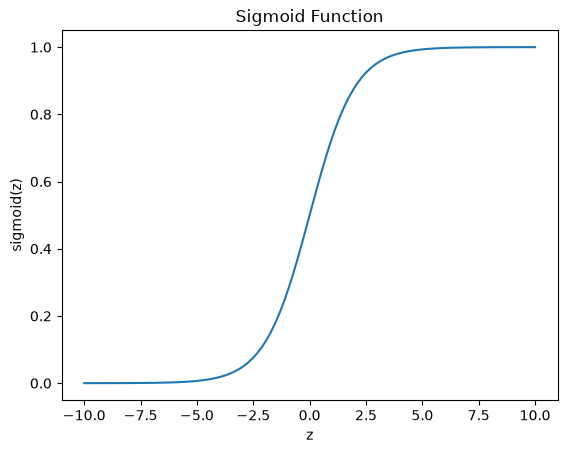

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

z = np.linspace(-10, 10, 100)
sigma_z = 1 / (1 + np.exp(-z))

plt.plot(z, sigma_z)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.show()


**Attributes**
* Approaches 1 when z is large and positive
* Approaches 0 when z is large and negative
* 0.5 when z is 0
* Ouput between 0 and 1
* Smooth and differentiable everywhere

### Efficient gradient computation
```
d(sigmoid(z))/dz =
    -1 * sigmoid(z)^2 * d(e^(-z))/dz =
    -1 * sigmoid(z)^2 * -e^(-z) =
    sigmoid(z) * (sigmoid(z) * e^(-z)) =
    sigmoid(z) * (1 - sigmoid(z))
```

### Logistic Regression = Linear Model + Sigmoid

```mermaid
flowchart LR
A[Input Features]--> B[Linear: z = wx + b] --> C["Sigmoid: p = 1/(1+e^-z)"] --> D[p >= 0.5?]
D--Yes--> E[Predict 1]
D--No--> F[Predict 0]
```

## Loss Function for 2D problem

### Binary cross-entroy

`Loss = -(1/n) * sum(y * log(p) + (1 - y) * log(1 - p))`

y --> Perdict value

### Gradint

`p = sigmoid(wx + b)`

...

`dL/dw = (1/n) * sum((p - y) * x)`

`dL/db = (1/n) * sum(p - y)`


## Loss Function for Multivariate problem

### Softmax

`softmax(z_i) = e^(z_i) / sum(e^(z_i) for all j)`

**softmax(z_i) is p_i, sum of (p_i) equals to 1**

`Loss = -(1/n) * sum( sum(y_k * log(p_k)) )`

## Evaluation Standards

### Confusion Matrix:

||Predicted Positive|Predicted Negative|
|---|---|---|
|Actually Positive|True Positive|False Negative|
|Actually Negative|False Positive|True Negative|

### Precision:

**Of all predicted positives, how may are actually positive**

`Precision = TP / (TP + FP)`

### Recall (Sensitivity)

**Of all actual positives, how may did we catch**

`Recall = TP / (TP + FN)`

### F1 Score

**Harmonic mean of precision and recall**

F1 = 2 * (Precision * Recall) / (Precision + Recall)

# Build your Own

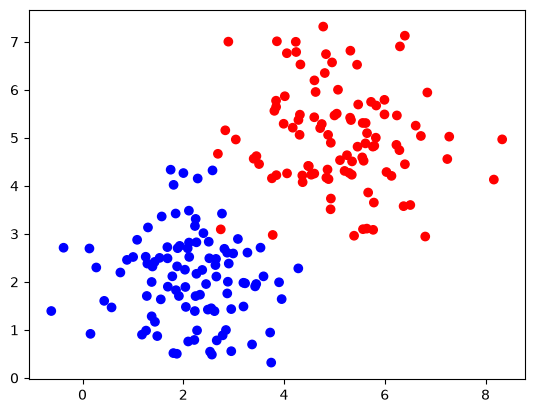

In [31]:
import random
import math

def sigmoid(z):
    z = max(-500, min(500, z))
    return 1.0 / (1.0 + math.exp(-z))

random.seed(42)
N = 200
X = []
y = []

for _ in range(N // 2):
    X.append([random.gauss(2, 1), random.gauss(2, 1)])
    y.append(0)

for _ in range(N // 2):
    X.append([random.gauss(5, 1), random.gauss(5, 1)])
    y.append(1)

plt.scatter(x = [x[0] for x in X], y = [x[1] for x in X], c=['red' if i == 1 else 'blue' for i in y])
plt.show()

combined = list(zip(X, y))
random.shuffle(combined)

X, y = zip(*combined)
X = list(X)
y = list(y)



=== Training Logistic Regression ===
  Epoch    0 | Loss: 0.6289 | w: [0.074, 0.070] | b: -0.001
  Epoch  200 | Loss: 0.3136 | w: [0.464, 0.333] | b: -2.402
  Epoch  400 | Loss: 0.2173 | w: [0.657, 0.497] | b: -3.756
  Epoch  600 | Loss: 0.1723 | w: [0.795, 0.608] | b: -4.684
  Epoch  800 | Loss: 0.1462 | w: [0.902, 0.693] | b: -5.391

Train accuracy: 0.9875
Test accuracy:  1.0000
Weights: [0.9886, 0.7629]
Bias: -5.9623


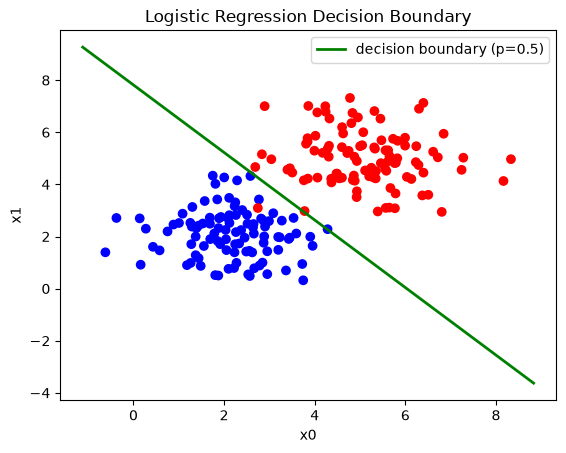

In [33]:
class LogisticRegression:
    def __init__(self, n_features, learning_rate=0.01):
        self.weights = [0.0] * n_features
        self.bias = 0.0
        self.lr = learning_rate
        self.loss_history = []

    def predict_proba(self, x):
        z = sum(w * xi for w, xi in zip(self.weights, x)) + self.bias
        return sigmoid(z)

    def predict(self, x, threshold=0.5):
        return 1 if self.predict_proba(x) >= threshold else 0

    def compute_loss(self, X, y):
        n = len(y)
        total = 0.0
        for i in range(n):
            p = self.predict_proba(X[i])
            p = max(1e-15, min(1 - 1e-15, p))
            total += y[i] * math.log(p) + (1 - y[i]) * math.log(1 - p)
        return -total / n

    def fit(self, X, y, epochs=1000, print_every=200):
        n = len(y)
        n_features = len(X[0])
        for epoch in range(epochs):
            dw = [0.0] * n_features
            db = 0.0
            for i in range(n):
                p = self.predict_proba(X[i])
                error = p - y[i]
                for j in range(n_features):
                    dw[j] += error * X[i][j]
                db += error
            for j in range(n_features):
                self.weights[j] -= self.lr * (dw[j] / n)
            self.bias -= self.lr * (db / n)
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if epoch % print_every == 0:
                print(f"  Epoch {epoch:4d} | Loss: {loss:.4f} | w: [{self.weights[0]:.3f}, {self.weights[1]:.3f}] | b: {self.bias:.3f}")
        return self

    def accuracy(self, X, y):
        correct = sum(1 for i in range(len(y)) if self.predict(X[i]) == y[i])
        return correct / len(y)


split = int(0.8 * N)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("\n=== Training Logistic Regression ===")
model = LogisticRegression(n_features=2, learning_rate=0.1)
model.fit(X_train, y_train, epochs=1000, print_every=200)

print(f"\nTrain accuracy: {model.accuracy(X_train, y_train):.4f}")
print(f"Test accuracy:  {model.accuracy(X_test, y_test):.4f}")
print(f"Weights: [{model.weights[0]:.4f}, {model.weights[1]:.4f}]")
print(f"Bias: {model.bias:.4f}")

## Draw scatter and decision boundary
# Decision boundary: p = 0.5  <=>  w0*x0 + w1*x1 + b = 0
# => x1 = -(w0*x0 + b) / w1
x0_vals = [x[0] for x in X]
x1_vals = [x[1] for x in X]
x0_line = np.linspace(min(x0_vals) - 0.5, max(x0_vals) + 0.5, 100)
w0, w1 = model.weights
x1_line = [-(w0 * x0 + model.bias) / w1 for x0 in x0_line]

plt.scatter(x=x0_vals, y=x1_vals, c=['red' if i == 1 else 'blue' for i in y])
plt.plot(x0_line, x1_line, color='green', linewidth=2, label='decision boundary (p=0.5)')
plt.xlabel('x0')
plt.ylabel('x1')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.show()



In [ ]:
class ClassificationMetrics:
    def __init__(self, y_true, y_pred):
        self.tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
        self.tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
        self.fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
        self.fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)

    def accuracy(self):
        total = self.tp + self.tn + self.fp + self.fn
        return (self.tp + self.tn) / total if total > 0 else 0

    def precision(self):
        denom = self.tp + self.fp
        return self.tp / denom if denom > 0 else 0

    def recall(self):
        denom = self.tp + self.fn
        return self.tp / denom if denom > 0 else 0

    def f1(self):
        p = self.precision()
        r = self.recall()
        return 2 * p * r / (p + r) if (p + r) > 0 else 0

    def print_confusion_matrix(self):
        print(f"\n  Confusion Matrix:")
        print(f"                  Predicted")
        print(f"                  Pos   Neg")
        print(f"  Actual Pos     {self.tp:4d}  {self.fn:4d}")
        print(f"  Actual Neg     {self.fp:4d}  {self.tn:4d}")

    def print_report(self):
        self.print_confusion_matrix()
        print(f"\n  Accuracy:  {self.accuracy():.4f}")
        print(f"  Precision: {self.precision():.4f}")
        print(f"  Recall:    {self.recall():.4f}")
        print(f"  F1 Score:  {self.f1():.4f}")


y_pred_test = [model.predict(x) for x in X_test]
print("\n=== Classification Report (Test Set) ===")
metrics = ClassificationMetrics(y_test, y_pred_test)
metrics.print_report()